DHIVYA A- 24BAD020
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)
Image size: 28 x 28


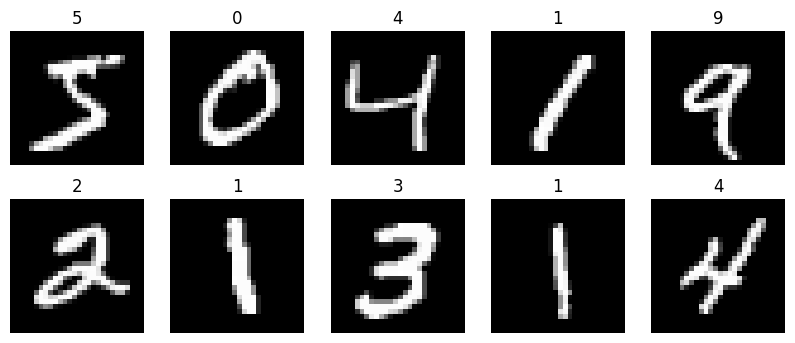

Minimum value: -1.0
Maximum value: 1.0
Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)
Batch image shape: (64, 28, 28, 1)
Batch label shape: (64,)
Data preprocessing completed successfully!


In [1]:
# PART A: DATASET PREPARATION AND IMAGE PREPROCESSING
print("DHIVYA A- 24BAD020")

import tensorflow as tf
import matplotlib.pyplot as plt
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
# Check dataset size and image dimensions
print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)
print("Image size:", x_train.shape[1], "x", x_train.shape[2])
# Display sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")
plt.show()
# Normalize pixel values from 0-255 to -1 to 1
x_train = (x_train.astype("float32") / 127.5) - 1
x_test = (x_test.astype("float32") / 127.5) - 1
# Check normalized values
print("Minimum value:", x_train.min())
print("Maximum value:", x_train.max())
# Reshape images by adding one channel
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Check new shape
print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

# Create TensorFlow dataset
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))

# Shuffle and create batches
train_dataset = train_dataset.shuffle(10000).batch(64)

# Check one batch
for images, labels in train_dataset.take(1):
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)

# Dataset preparation completed
print("Data preprocessing completed successfully!")


DHIVYA A- 24BAD020


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ ?                      │   0 (unbuilt) │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ ?                      │   0 (unbuilt) │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

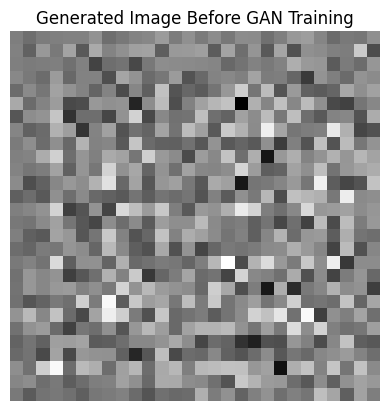

Generated image shape: (1, 28, 28, 1)
Generator image generated successfully!


In [4]:
# PART B: IMPLEMENTING THE GENERATOR
print("DHIVYA A- 24BAD020")
import tensorflow as tf
import matplotlib.pyplot as plt
# Define random noise size
NOISE_DIM = 100
# Create Generator model
generator = tf.keras.Sequential([
    # Convert noise into a larger feature map
    tf.keras.layers.Dense(7 * 7 * 128, use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),
    # Reshape into image format
    tf.keras.layers.Reshape((7, 7, 128)),
    # Upsample from 7x7 to 14x14
    tf.keras.layers.Conv2DTranspose(
        64, (5, 5), strides=(2, 2), padding="same",
        use_bias=False
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),
    # Upsample from 14x14 to 28x28
    tf.keras.layers.Conv2DTranspose(
        1, (5, 5), strides=(2, 2), padding="same",
        use_bias=False, activation="tanh"
    )
])
# Display Generator architecture
generator.summary()

# Create random noise
noise = tf.random.normal([1, NOISE_DIM])
# Generate an image
generated_image = generator(noise, training=False)
# Display generated image
plt.imshow(generated_image[0, :, :, 0], cmap="gray")
plt.title("Generated Image Before GAN Training")
plt.axis("off")
plt.show()
# Display generated image shape
print("Generated image shape:", generated_image.shape)
print("Generator image generated successfully!")


In [5]:
# PART C: IMPLEMENTING THE DISCRIMINATOR AND GAN MODEL
print("DHIVYA A- 24BAD020")
import tensorflow as tf
# Create Discriminator model
discriminator = tf.keras.Sequential([
    # Convolutional layer
    tf.keras.layers.Conv2D(
        64, (5, 5), strides=(2, 2),
        padding="same", input_shape=(28, 28, 1)
    ),
    tf.keras.layers.LeakyReLU(),
    # Second convolutional layer
    tf.keras.layers.Conv2D(
        128, (5, 5), strides=(2, 2),
        padding="same"
    ),
    tf.keras.layers.LeakyReLU(),
    # Flatten the features
    tf.keras.layers.Flatten(),
    # Final binary classification layer
    tf.keras.layers.Dense(1, activation="sigmoid")
])
# Compile the Discriminator
discriminator.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
# Display Discriminator summary
print("\n--- DISCRIMINATOR SUMMARY ---")
discriminator.summary()
# Create Generator
NOISE_DIM = 100
generator = tf.keras.Sequential([
    tf.keras.layers.Dense(7 * 7 * 128, use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Reshape((7, 7, 128)),
    tf.keras.layers.Conv2DTranspose(
        64, (5, 5), strides=(2, 2),
        padding="same", use_bias=False
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),

    tf.keras.layers.Conv2DTranspose(
        1, (5, 5), strides=(2, 2),
        padding="same",
        use_bias=False,
        activation="tanh"
    )
])

# Display Generator summary
print("\n--- GENERATOR SUMMARY ---")
generator.summary()

# Create GAN model
discriminator.trainable = False

gan = tf.keras.Sequential([
    generator,
    discriminator
])

# Compile GAN
gan.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
    loss="binary_crossentropy"
)

# Display GAN summary
print("\n--- GAN SUMMARY ---")
gan.summary()

print("\nDiscriminator and GAN created successfully!")


DHIVYA A- 24BAD020

--- DISCRIMINATOR SUMMARY ---


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 1)              │       212,865 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 212,865 (831.50 KB)


Discriminator and GAN created successfully!


DHIVYA A- 24BAD020


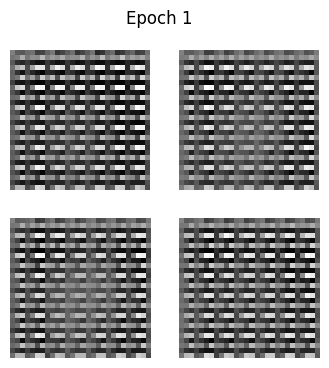

Epoch: 1 Generator Loss: 1.373 Discriminator Loss: 0.82


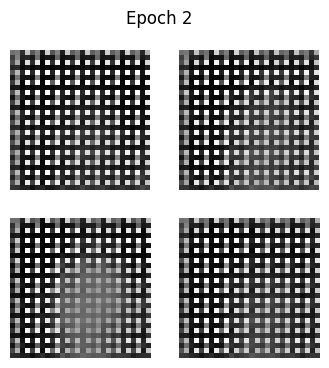

Epoch: 2 Generator Loss: 3.099 Discriminator Loss: 0.226


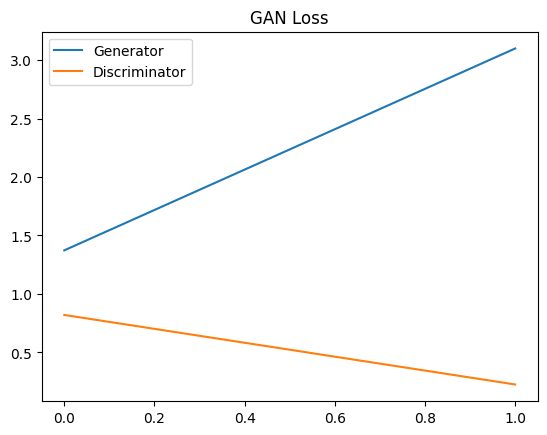

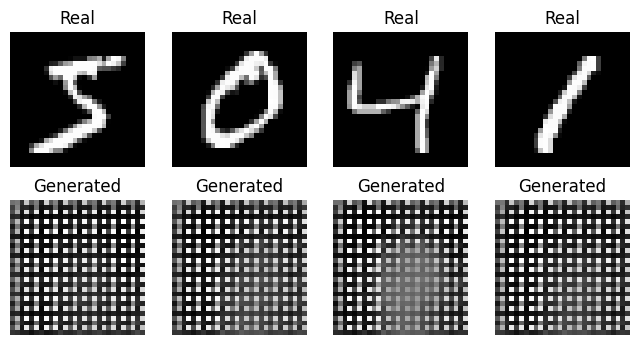

Training completed!
Generated images saved!


In [7]:
# PART D: GAN TRAINING AND SYNTHETIC IMAGE GENERATION
print("DHIVYA A- 24BAD020")
import tensorflow as tf
import matplotlib.pyplot as plt
# Load and prepare MNIST
(x, _), (_, _) = tf.keras.datasets.mnist.load_data()
x = (x[:1000].astype("float32") / 127.5) - 1
x = x.reshape(-1, 28, 28, 1)
# Create Generator
G = tf.keras.Sequential([
    tf.keras.layers.Dense(7*7*64, activation="relu"),
    tf.keras.layers.Reshape((7,7,64)),
    tf.keras.layers.Conv2DTranspose(32, 5, 2, padding="same",
                                     activation="relu"),
    tf.keras.layers.Conv2DTranspose(1, 5, 2, padding="same",
                                     activation="tanh")
])
# Create Discriminator
D = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 5, 2, padding="same",
                           input_shape=(28,28,1)),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1)
])
# Loss and optimizers
loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)
go = tf.keras.optimizers.Adam(0.001)
do = tf.keras.optimizers.Adam(0.001)

# Training
gl, dl = [], []
for epoch in range(2):
    for real in tf.data.Dataset.from_tensor_slices(x).batch(32):
        # Random noise and fake images
        noise = tf.random.normal([len(real), 100])
        # Train Discriminator
        with tf.GradientTape() as t:
            fake = G(noise, training=True)
            d_loss = loss(tf.ones((len(real),1)), D(real)) + \
                     loss(tf.zeros((len(real),1)), D(fake))
        do.apply_gradients(zip(t.gradient(d_loss, D.trainable_variables),
                               D.trainable_variables))
        # Train Generator
        with tf.GradientTape() as t:
            fake = G(noise, training=True)
            g_loss = loss(tf.ones((len(real),1)), D(fake))
        go.apply_gradients(zip(t.gradient(g_loss, G.trainable_variables),
                               G.trainable_variables))
    gl.append(float(g_loss))
    dl.append(float(d_loss))
    # Generate images at training interval
    noise = tf.random.normal([4, 100])
    img = G(noise, training=False)
    plt.figure(figsize=(4,4))
    for i in range(4):
        plt.subplot(2,2,i+1)
        plt.imshow((img[i,:,:,0]+1)/2, cmap="gray")
        plt.axis("off")
    plt.suptitle("Epoch " + str(epoch+1))
    plt.show()
    print("Epoch:", epoch+1,
          "Generator Loss:", round(gl[-1],3),
          "Discriminator Loss:", round(dl[-1],3))
# Loss graph
plt.plot(gl, label="Generator")
plt.plot(dl, label="Discriminator")
plt.legend()
plt.title("GAN Loss")
plt.show()
# Compare real and generated images
plt.figure(figsize=(8,4))
for i in range(4):
    plt.subplot(2,4,i+1)
    plt.imshow((x[i,:,:,0]+1)/2, cmap="gray")
    plt.title("Real")
    plt.axis("off")
    plt.subplot(2,4,i+5)
    plt.imshow((img[i,:,:,0]+1)/2, cmap="gray")
    plt.title("Generated")
    plt.axis("off")
plt.show()
# Save final generated images
for i in range(4):
    plt.imsave("generated_"+str(i+1)+".png",
               (img[i,:,:,0]+1)/2, cmap="gray")

print("Training completed!")
print("Generated images saved!")
